In [ ]:
import pandas as pd
from pathlib import Path

# adjust path if needed
parquet_path = Path("data/derivatives/nflx/segments_nflx_v1.parquet")
segments = pd.read_parquet(parquet_path)

target_columns = [
    "target__powell",
    "target__chair_powell",
    "target__credit",
    "target__pandemic",
    "target__obvious",
    "target__recession",
    "target__volatility",
    "target__median",
    "target__tax",
    "target__restrictive",
    "target__goods_inflation",
    "target__balance_sheet",
    "target__growth",
    "target__balance_of_risk",
    "target__probability",
    "target__pardon",
    "target__anchor",
    "target__gold",
    "target__bitcoin",
    "target__national_debt",
    "target__soft_landing",
    "target__trade_war",
    "target__yield_curve",
    "target__good_afternoon",
    "target__data",
    "target__expectation",
    "target__projection",
]


In [2]:
# event-level label = did he say it at least once in that conference?
event_flags = (
    segments.groupby("event_id")[target_columns]
    .max()
    .reset_index()
)

# compute base rate across events for each target, sorted
base_rates = (
    event_flags[target_columns]
    .mean()
    .sort_values(ascending=False)
    .rename("historical_prob")
    .to_frame()
)
base_rates.index = base_rates.index.str.replace("target__", "", regex=False)
base_rates


,historical_prob
powell,1.000000
chair_powell,1.000000
data,1.000000
restrictive,0.933333
expectation,0.933333
growth,0.933333
pandemic,0.933333
balance_of_risk,0.933333
anchor,0.866667
good_afternoon,0.866667


In [3]:
target = "target__credit"  # change as needed

# per-event indicator + optional dates if present
cols = ["event_id", target]
if "event_date" in segments.columns:
    cols.append("event_date")

ev = (
    segments[cols]
    .groupby("event_id", as_index=False)
    .max()
    .sort_values(cols[-1] if "event_date" in cols else "event_id")
    .rename(columns={target: "mentioned"})
)

ev

,event_id,mentioned,event_date
1,FOMC_JAN2024,False,2024-01-31
7,FOMC_MAR2024,False,2024-03-20
9,FOMC_MAY2024,True,2024-05-01
5,FOMC_JUN2024,True,2024-06-12
3,FOMC_JUL2024,False,2024-07-31
12,FOMC_SEP2024,False,2024-09-18
11,FOMC_NOV2024,False,2024-11-07
0,FOMC_DEC2024,True,2024-12-18
2,FOMC_JAN2025,False,2025-01-29
8,FOMC_MAR2025,False,2025-03-19


In [4]:
import numpy as np

def wilson_interval(k, n, z=1.96):  # 95% CI by default
    if n == 0:
        return (0.0, 1.0)
    phat = k / n
    denom = 1 + z**2 / n
    centre = phat + z**2 / (2*n)
    adj = z * np.sqrt((phat*(1-phat) + z**2/(4*n)) / n)
    lo = (centre - adj) / denom
    hi = (centre + adj) / denom
    return float(max(0, lo)), float(min(1, hi))

# build CI table for all targets
event_counts = (segments.groupby("event_id")[target_columns].max())
n_events = len(event_counts)

rows = []
for tc in target_columns:
    k = int(event_counts[tc].sum())  # number of events where mentioned ≥1x
    lo, hi = wilson_interval(k, n_events)
    rows.append({"target": tc.replace("target__", ""), "k": k, "n": n_events,
                 "prob": k/n_events, "ci_lo": lo, "ci_hi": hi})

ci_df = pd.DataFrame(rows).sort_values("prob", ascending=False).reset_index(drop=True)
ci_df

,target,k,n,prob,ci_lo,ci_hi
0,powell,15,15,1.000000,0.796111,1.000000
1,chair_powell,15,15,1.000000,0.796111,1.000000
2,data,15,15,1.000000,0.796111,1.000000
3,restrictive,14,15,0.933333,0.701829,0.988133
4,expectation,14,15,0.933333,0.701829,0.988133
5,growth,14,15,0.933333,0.701829,0.988133
6,pandemic,14,15,0.933333,0.701829,0.988133
7,balance_of_risk,14,15,0.933333,0.701829,0.988133
8,anchor,13,15,0.866667,0.621175,0.962640
9,good_afternoon,13,15,0.866667,0.621175,0.962640


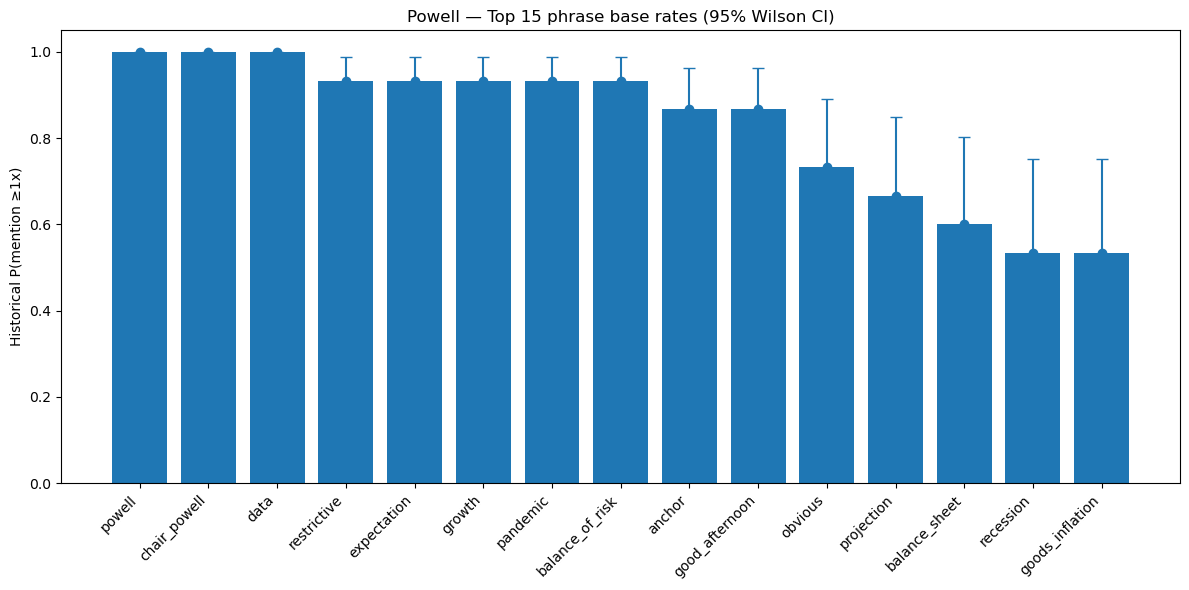

In [5]:
import matplotlib.pyplot as plt

top_n = 15
top = ci_df.head(top_n).copy()

x = np.arange(len(top))
y = top["prob"].values
yerr = np.vstack([y - top["ci_lo"].values, top["ci_hi"].values - y])

plt.figure(figsize=(12, 6))
plt.bar(x, y)
plt.errorbar(x, y, yerr=yerr, fmt='o', capsize=4)
plt.xticks(x, top["target"].tolist(), rotation=45, ha="right")
plt.ylabel("Historical P(mention ≥1x)")
plt.title(f"Powell — Top {top_n} phrase base rates (95% Wilson CI)")
plt.tight_layout()
plt.show()


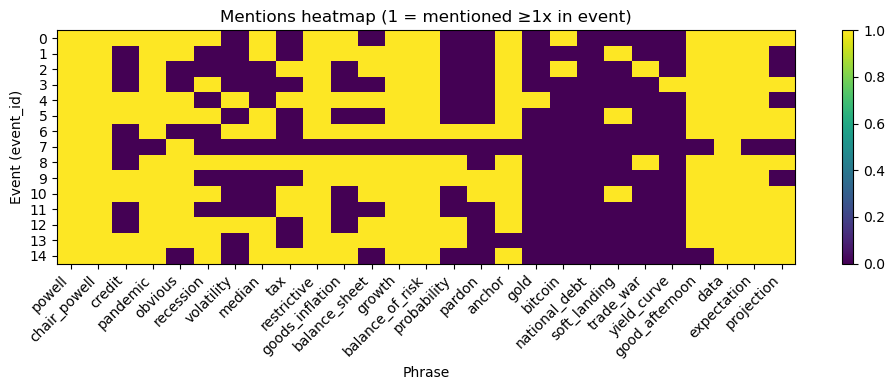

In [13]:
# subset_targets = [
#     "target__credit", "target__recession",
#     "target__inflation" if "target__inflation" in event_flags.columns else "target__growth",
#     "target__balance_sheet", "target__yield_curve", "target__bitcoin", "target__gold"
# ]
subset_targets = [t for t in target_columns if t in event_flags.columns]

if "event_date" in segments.columns:
    ev_dates = segments[["event_id", "event_date"]].drop_duplicates().set_index("event_id")
    ev_flags = event_flags.join(ev_dates, how="left").sort_values("event_date")
else:
    ev_flags = event_flags.copy()

if subset_targets:
    mat = ev_flags[subset_targets].astype(int).values
    plt.figure(figsize=(10, max(4, mat.shape[0]*0.2)))
    plt.imshow(mat, aspect="auto", interpolation="nearest")
    plt.yticks(np.arange(ev_flags.shape[0]), ev_flags.index.tolist())
    plt.xticks(np.arange(len(subset_targets)), [t.replace("target__", "") for t in subset_targets], rotation=45, ha="right")
    plt.xlabel("Phrase")
    plt.ylabel("Event (event_id)")
    plt.title("Mentions heatmap (1 = mentioned ≥1x in event)")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


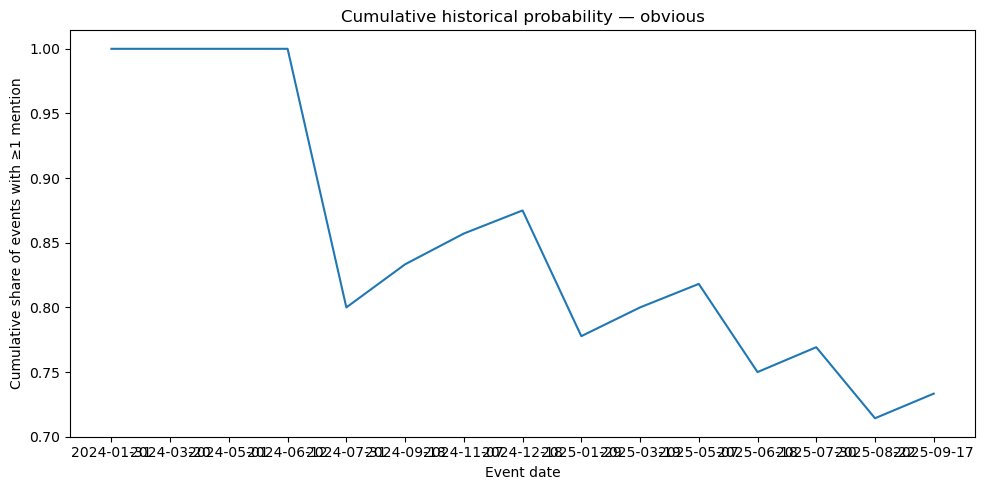

In [11]:
target = "target__obvious"  # change freely

if "event_date" in segments.columns:
    ev = segments[["event_id","event_date",target]].groupby(["event_id","event_date"], as_index=False).max().sort_values("event_date")
    x = ev["event_date"]
else:
    ev = segments[["event_id",target]].groupby("event_id", as_index=False).max().sort_values("event_id")
    ev["idx"] = np.arange(1, len(ev)+1)
    x = ev["idx"]

ev["cum_mentioned"] = ev[target].cumsum()
ev["cum_share"] = ev["cum_mentioned"] / (np.arange(1, len(ev)+1))

plt.figure(figsize=(10,5))
plt.plot(x, ev["cum_share"])
plt.xlabel("Event date" if "event_date" in segments.columns else "Event index")
plt.ylabel("Cumulative share of events with ≥1 mention")
plt.title(f"Cumulative historical probability — {target.replace('target__','')}")
plt.tight_layout()
plt.show()


In [12]:
def implied_prob_from_decimal(decimal_odds: float) -> float:
    return 1.0 / decimal_odds

def kelly_edge(bp: float, mp: float) -> float:
    # Kelly numerator: (bp - mp) / (1 - mp); >0 → +EV
    return (bp - mp) / (1 - mp)

# Example: market offers YES at 1.80 (≈55.6%)
phrase = "obvious"
my_p = float(ci_df.loc[ci_df["target"]==phrase, "prob"])
conservative_p = float(ci_df.loc[ci_df["target"]==phrase, "ci_lo"])

# market_decimal = 1.80
# market_p = implied_prob_from_decimal(market_decimal)
market_p = 0.43

print({
    "phrase": phrase,
    "my_prob": round(my_p, 3),
    "conservative_prob": round(conservative_p, 3),
    "market_prob": round(market_p, 3),
    "edge_prob_based": round(kelly_edge(my_p, market_p), 4),
    "edge_conservative": round(kelly_edge(conservative_p, market_p), 4),
})


{'phrase': 'obvious', 'my_prob': 0.733, 'conservative_prob': 0.48, 'market_prob': 0.43, 'edge_prob_based': 0.5322, 'edge_conservative': 0.0886}


/var/folders/p3/svv3_rhn7mlfyw2x0bgcq_k40000gn/T/ipykernel_44889/1779216632.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  my_p = float(ci_df.loc[ci_df["target"]==phrase, "prob"])
/var/folders/p3/svv3_rhn7mlfyw2x0bgcq_k40000gn/T/ipykernel_44889/1779216632.py:11: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  conservative_p = float(ci_df.loc[ci_df["target"]==phrase, "ci_lo"])


In [9]:
import json, statistics as stats
from pathlib import Path

exp_dir = Path("experiments/powell_baseline")
files = sorted(exp_dir.glob("fold_*_metrics.json"))

metrics = []
for fp in files:
    with open(fp) as f:
        j = json.load(f)
    # keep the common ones
    metrics.append({
        "file": fp.name,
        "log_loss": j.get("log_loss"),
        "brier": j.get("brier"),
        "roc_auc": j.get("roc_auc"),
        "avg_prec": j.get("average_precision"),
        "accuracy": j.get("accuracy"),
        "precision": j.get("precision"),
        "recall": j.get("recall"),
        "f1": j.get("f1"),
    })

m = pd.DataFrame(metrics)
summary = m.describe().loc[["mean","min","max"]]
m, summary


(                    file  log_loss     brier   roc_auc  avg_prec  accuracy  \
 0    fold_0_metrics.json  0.115002  0.019015  1.000000       1.0  0.981481   
 1   fold_10_metrics.json  0.124768  0.021749  1.000000       1.0  0.978723   
 2   fold_11_metrics.json  0.098008  0.009261       NaN       0.0  1.000000   
 3   fold_12_metrics.json  0.099166  0.009322       NaN       0.0  1.000000   
 4   fold_13_metrics.json  0.159645  0.036460  0.968085       0.7  0.959184   
 5   fold_14_metrics.json  0.160113  0.035662  1.000000       1.0  0.960000   
 6    fold_1_metrics.json  0.107795  0.011048       NaN       0.0  1.000000   
 7    fold_2_metrics.json  0.103086  0.009978       NaN       0.0  1.000000   
 8    fold_3_metrics.json  0.098770  0.009246       NaN       0.0  1.000000   
 9    fold_4_metrics.json  0.128170  0.022499  1.000000       1.0  0.977273   
 10   fold_5_metrics.json  0.113274  0.016731  1.000000       1.0  0.980392   
 11   fold_6_metrics.json  0.106083  0.010518       

In [10]:
for _, r in ci_df.iterrows():
    print(f"{r['target']:<22} prob={r['prob']:.3f}  CI95%[{r['ci_lo']:.3f},{r['ci_hi']:.3f}]  k/n={r['k']}/{r['n']}")


powell                 prob=1.000  CI95%[0.796,1.000]  k/n=15/15
chair_powell           prob=1.000  CI95%[0.796,1.000]  k/n=15/15
data                   prob=1.000  CI95%[0.796,1.000]  k/n=15/15
restrictive            prob=0.933  CI95%[0.702,0.988]  k/n=14/15
expectation            prob=0.933  CI95%[0.702,0.988]  k/n=14/15
growth                 prob=0.933  CI95%[0.702,0.988]  k/n=14/15
pandemic               prob=0.933  CI95%[0.702,0.988]  k/n=14/15
balance_of_risk        prob=0.933  CI95%[0.702,0.988]  k/n=14/15
anchor                 prob=0.867  CI95%[0.621,0.963]  k/n=13/15
good_afternoon         prob=0.867  CI95%[0.621,0.963]  k/n=13/15
obvious                prob=0.733  CI95%[0.480,0.891]  k/n=11/15
projection             prob=0.667  CI95%[0.417,0.848]  k/n=10/15
balance_sheet          prob=0.600  CI95%[0.357,0.802]  k/n=9/15
recession              prob=0.533  CI95%[0.301,0.752]  k/n=8/15
goods_inflation        prob=0.533  CI95%[0.301,0.752]  k/n=8/15
median                 prob=